# Complete single-source analysis of a real multiwavelength light curve

This maintained notebook runs the bundled source
`examples/data/10131+3049.csv` through the complete public PGMUVI workflow:
validation, sampling and variability inspection, independent period evidence
for every observational channel, temporal consensus, wavelength-derived
constraints, a real two-dimensional GP fit, predictions, plots, residuals,
phase diagnostics, fitted parameters, noise provenance, warnings, and a
JSON-safe structured report.


## Scope and scientific boundaries

The workflow uses **linear flux**, with time in input dimension 0 and physical
wavelength in dimension 1. All observational channels—including both KELT
channels at the shared physical wavelength—contribute to period evidence and
consensus. The final GP training scope explicitly selects
`KELT/OSN_Johnson.Cousins_R3_0` at the duplicated wavelength and reports the
ignored channel. This is a computational identifiability choice, not an instrument-channel calibration.

The required path fits one `2DWavelengthDependent` GP with a quasi-periodic time
kernel and an RBF wavelength kernel. Other model families are not automatically
selected from this single source.


In [1]:
from pathlib import Path
import warnings

from IPython.display import HTML, display
import matplotlib.pyplot as plt
import numpy as np
import torch
from gpytorch.utils.warnings import GPInputWarning

from pgmuvi.single_source_analysis import (
    SINGLE_SOURCE_ANALYSIS_STAGE_ORDER,
    build_per_observational_channel_period_evidence,
    build_phase_folded_prediction_summary,
    build_single_source_analysis_report,
    preserve_single_source_analysis_state,
    single_source_json_safe,
    summarize_single_source_fit_quality,
    summarize_single_source_noise_provenance,
    summarize_single_source_observational_channels,
    validate_single_source_stage_records,
    write_single_source_analysis_report,
)
from pgmuvi.wavelength_constraint_tutorial import (
    build_tutorial_fit_summary,
    build_wavelength_constraint_position_rows,
    load_wavelength_constraint_tutorial_lightcurve,
    summarize_observational_channel_residuals,
    training_point_prediction_summary,
)

SEED = 174
RUN_REQUIRED_FIT = True
WRITE_JSON_REPORT = False
MAX_SAMPLES_PER_OBSERVATIONAL_CHANNEL = 50
TRAINING_ITER = 200
MINITER = 100
DUPLICATE_WAVELENGTH_SELECTION = {
    0.6561154962791801: "KELT/OSN_Johnson.Cousins_R3_0",
}

def find_repository_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "examples/data/10131+3049.csv").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the PGMUVI repository root.")

def display_records(records, columns=None, title=None):
    if not records:
        display(HTML("<p><em>No records.</em></p>"))
        return
    columns = list(columns or records[0])
    heading = f"<h4>{title}</h4>" if title else ""
    head = "".join(f"<th>{column}</th>" for column in columns)
    body = []
    for record in records:
        cells = []
        for column in columns:
            value = record.get(column)
            if isinstance(value, float):
                value = f"{value:.6g}"
            cells.append(f"<td>{value}</td>")
        body.append("<tr>" + "".join(cells) + "</tr>")
    display(
        HTML(
            heading
            + "<table><thead><tr>"
            + head
            + "</tr></thead><tbody>"
            + "".join(body)
            + "</tbody></table>"
        )
    )

REPOSITORY_ROOT = find_repository_root()
SOURCE_CSV = REPOSITORY_ROOT / "examples/data/10131+3049.csv"
REPORT_PATH = REPOSITORY_ROOT / "single_source_analysis_report.json"
stage_records = []

{
    "source": str(SOURCE_CSV.relative_to(REPOSITORY_ROOT)),
    "required_fit": RUN_REQUIRED_FIT,
    "maximum_rows_per_observational_channel": (
        MAX_SAMPLES_PER_OBSERVATIONAL_CHANNEL
    ),
    "training_iter": TRAINING_ITER,
    "miniter": MINITER,
    "default_dtype_inside_analysis_stages": "torch.float64",
}


{'source': 'examples/data/10131+3049.csv',
 'required_fit': True,
 'maximum_rows_per_observational_channel': 50,
 'training_iter': 200,
 'miniter': 100,
 'default_dtype_inside_analysis_stages': 'torch.float64'}

## 1. Load, validate, and inspect the retained source

Rows must have finite time, flux, uncertainty, and wavelength; flux and
uncertainty must both be strictly positive; and every row must retain a
non-empty observational-channel label. Deterministic time-stratified sampling
limits exact-GP cost without dropping any observational channel or physical
wavelength.


In [2]:
with preserve_single_source_analysis_state(
    seed=SEED,
    default_dtype=torch.float64,
    working_directory=REPOSITORY_ROOT,
):
    lightcurve, sampling_summary = (
        load_wavelength_constraint_tutorial_lightcurve(
            SOURCE_CSV,
            max_samples_per_observational_channel=(
                MAX_SAMPLES_PER_OBSERVATIONAL_CHANNEL
            ),
            name="10131+3049 complete single-source analysis",
        )
    )
    input_summary = summarize_single_source_observational_channels(
        lightcurve
    )

assert sampling_summary["n_rows_original"] == 10815
assert sampling_summary["n_rows_eligible"] == 10815
assert sampling_summary["n_rows_excluded_by_validity_policy"] == 0
assert input_summary["dimension_order"] == ["time", "physical_wavelength"]
assert input_summary["flux_domain"] == "linear"
assert input_summary["n_observational_channels"] == 17
assert input_summary["n_physical_wavelengths"] == 16
assert input_summary["duplicate_physical_wavelength_groups"]
assert input_summary["duplicate_physical_wavelength_groups"][0][
    "observational_channels"
] == [
    "KELT/OSN_Johnson.Cousins_R3_0",
    "KELT/OSN_Johnson.Cousins_R3_1",
]

stage_records.extend(
    [
        {"stage": "load_and_validate", "status": "completed"},
        {"stage": "sampling_and_variability", "status": "completed"},
    ]
)

display_records(
    [
        {
            "original rows": sampling_summary["n_rows_original"],
            "eligible rows": sampling_summary["n_rows_eligible"],
            "retained rows": sampling_summary["n_rows_retained"],
            "observational channels": input_summary[
                "n_observational_channels"
            ],
            "physical wavelengths": input_summary[
                "n_physical_wavelengths"
            ],
            "flux domain": input_summary["flux_domain"],
        }
    ],
    title="Validated source and deterministic GP sample",
)


original rows,eligible rows,retained rows,observational channels,physical wavelengths,flux domain
10815,10815,519,17,16,linear


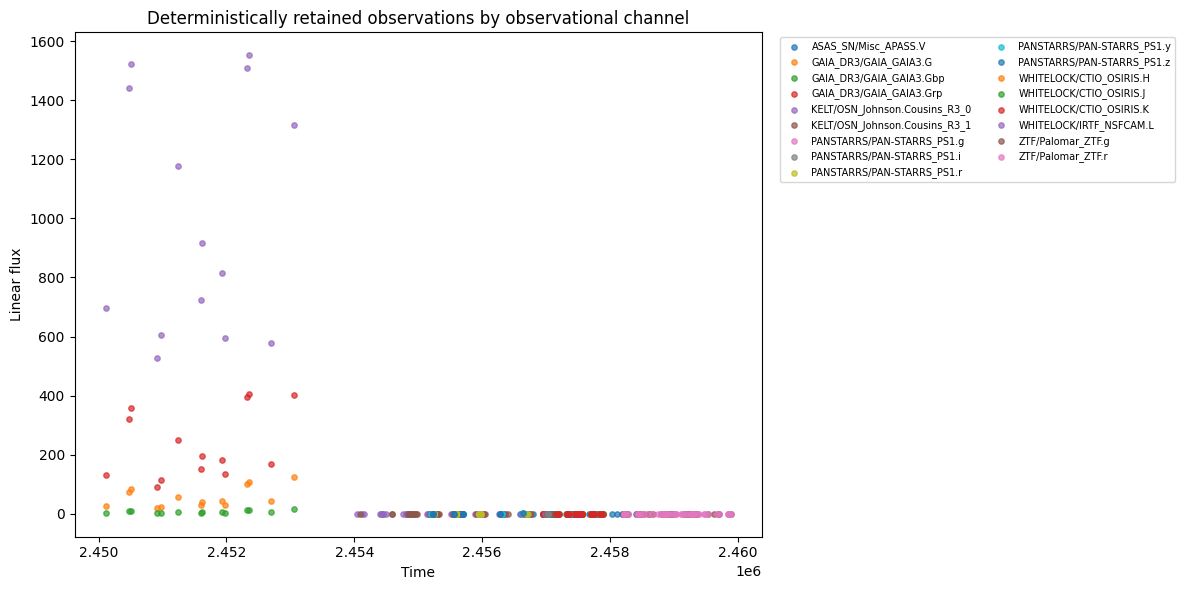

In [3]:
input_time = lightcurve.xdata[:, 0].detach().cpu().numpy()
input_flux = lightcurve.ydata.detach().cpu().numpy()
input_channels = np.asarray(
    lightcurve.observational_channel_labels,
    dtype=str,
)

with preserve_single_source_analysis_state(seed=SEED):
    fig, ax = plt.subplots(figsize=(12, 6))
    for observational_channel in dict.fromkeys(input_channels.tolist()):
        channel_mask = input_channels == observational_channel
        ax.scatter(
            input_time[channel_mask],
            input_flux[channel_mask],
            s=15,
            alpha=0.7,
            label=observational_channel,
        )
    ax.set_xlabel("Time")
    ax.set_ylabel("Linear flux")
    ax.set_title(
        "Deterministically retained observations by observational channel"
    )
    ax.legend(
        fontsize=7,
        ncol=2,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    fig.tight_layout()
    plt.show()


## 2. Independent period evidence for every observational channel

Lomb–Scargle and data-ACF diagnostics are calculated separately for all 17
observational channels. A failure in one channel is recorded rather than
silently removing evidence from the rest. ACF maxima remain diagnostics and are
not substituted for the temporal consensus.


In [4]:
with preserve_single_source_analysis_state(
    seed=SEED,
    default_dtype=torch.float64,
):
    period_evidence = build_per_observational_channel_period_evidence(
        lightcurve,
        num_peaks=3,
        single_threshold=0.05,
        nyquist_factor=5,
        acf_n_lags=50,
        minimum_points=5,
    )

assert period_evidence["all_channels_retained_for_consensus"] is True
assert period_evidence["n_observational_channels"] == 17
assert len(period_evidence["rows"]) == 17
assert {
    row["observational_channel"] for row in period_evidence["rows"]
} >= {
    "KELT/OSN_Johnson.Cousins_R3_0",
    "KELT/OSN_Johnson.Cousins_R3_1",
}

stage_records.append(
    {
        "stage": "per_observational_channel_period_evidence",
        "status": "completed",
        "available": period_evidence["n_available"],
        "unavailable": period_evidence["n_unavailable"],
    }
)

period_rows = []
for row in period_evidence["rows"]:
    lomb_scargle = row.get("lomb_scargle") or {}
    periods = lomb_scargle.get("peak_periods") or []
    significant = lomb_scargle.get("significant") or []
    period_rows.append(
        {
            "observational channel": row["observational_channel"],
            "physical wavelength": row["physical_wavelengths"][0],
            "points": row["n_points"],
            "status": row["status"],
            "dominant LS period": periods[0] if periods else None,
            "dominant significant": (
                significant[0] if significant else None
            ),
            "strongest positive ACF lag": (
                (row.get("acf") or {}).get("strongest_positive_lag")
            ),
            "reason": row.get("reason"),
        }
    )

display_records(period_rows, title="Per-observational-channel period evidence")


observational channel,physical wavelength,points,status,dominant LS period,dominant significant,strongest positive ACF lag,reason
ASAS_SN/Misc_APASS.V,0.541917,50,available,597.083,True,638.58,None
GAIA_DR3/GAIA_GAIA3.G,0.621759,50,available,628.467,True,108.411,None
GAIA_DR3/GAIA_GAIA3.Gbp,0.510971,50,available,554.53,True,23.5675,None
GAIA_DR3/GAIA_GAIA3.Grp,0.776902,50,available,628.467,True,23.5675,None
KELT/OSN_Johnson.Cousins_R3_0,0.656115,50,available,609.574,True,14.9346,None
KELT/OSN_Johnson.Cousins_R3_1,0.656115,50,available,597.366,True,1214.74,None
PANSTARRS/PAN-STARRS_PS1.g,0.484911,12,available,180.485,False,11.0998,None
PANSTARRS/PAN-STARRS_PS1.i,0.753496,17,available,582.613,True,388.311,None
PANSTARRS/PAN-STARRS_PS1.r,0.62012,15,available,39.8927,True,36.6016,None
PANSTARRS/PAN-STARRS_PS1.y,0.962779,6,available,110.623,True,7.24579,None


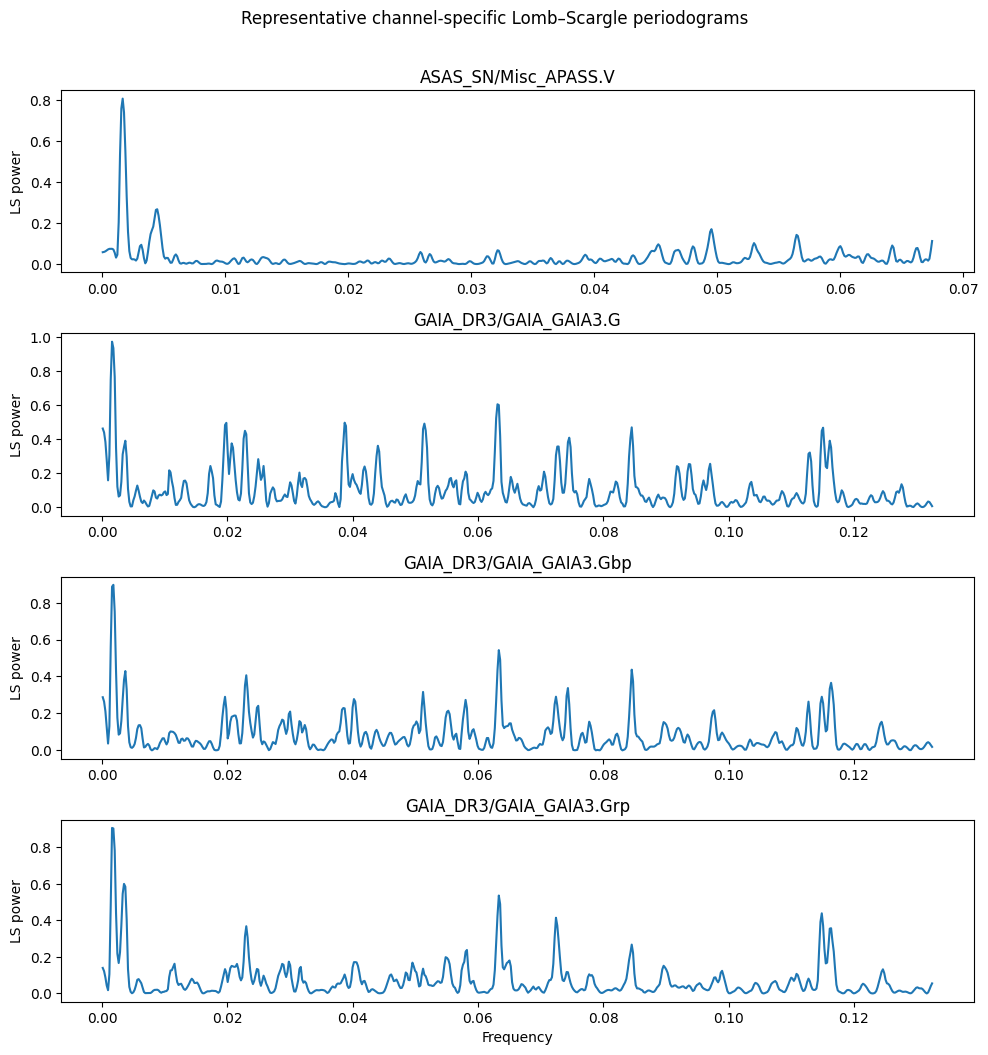

In [5]:
available_period_rows = [
    row for row in period_evidence["rows"]
    if row["status"] == "available"
]
plot_rows = sorted(
    available_period_rows,
    key=lambda row: row["n_points"],
    reverse=True,
)[:4]

with preserve_single_source_analysis_state(seed=SEED):
    fig, axes = plt.subplots(
        len(plot_rows),
        1,
        figsize=(10, 2.6 * len(plot_rows)),
        sharex=False,
    )
    axes = np.atleast_1d(axes)
    for ax, row in zip(axes, plot_rows, strict=True):
        frequency = np.asarray(
            row["lomb_scargle"]["frequency_grid"],
            dtype=float,
        )
        power = np.asarray(
            row["lomb_scargle"]["power_grid"],
            dtype=float,
        )
        ax.plot(frequency, power)
        ax.set_ylabel("LS power")
        ax.set_title(row["observational_channel"])
    axes[-1].set_xlabel("Frequency")
    fig.suptitle(
        "Representative channel-specific Lomb–Scargle periodograms",
        y=1.01,
    )
    fig.tight_layout()
    plt.show()


## 3. Temporal consensus, wavelength constraints, and the required GP fit

`fit_strategy="consensus"` first evaluates the retained observational channels
and constructs a shared temporal estimate. Before optimizer training, PGMUVI
builds and applies the model's data-derived parameter workflow, including the
wavelength-coordinate initialization and live interval constraints. PR172 keeps
both KELT channels in the consensus scope and applies the explicit selection
only when entering the exact-GP training scope.


In [6]:
FIT_KWARGS = {
    "model": "2DWavelengthDependent",
    "fit_strategy": "consensus",
    "time_kernel_type": "quasi_periodic",
    "wavelength_kernel_type": "rbf",
    "constraint_set": "LPV",
    "training_iter": TRAINING_ITER,
    "miniter": MINITER,
    "optim": "Adam",
    "lr": 0.03,
    "learn_additional_noise": True,
    "use_parameter_workflow": True,
    "duplicate_wavelength_policy": "select",
    "duplicate_wavelength_selection": DUPLICATE_WAVELENGTH_SELECTION,
    "verbose": False,
}

assert RUN_REQUIRED_FIT, "The default Run All path must execute the GP fit."
assert FIT_KWARGS["training_iter"] > 0
assert FIT_KWARGS["miniter"] > 0

with preserve_single_source_analysis_state(
    seed=SEED,
    default_dtype=torch.float64,
):
    with warnings.catch_warnings(record=True) as fit_warning_records:
        warnings.simplefilter("always")
        fit_result = lightcurve.fit(**FIT_KWARGS)

fit_warning_messages = [
    str(item.message) for item in fit_warning_records
]
fit_history = lightcurve.get_fit_history()
latest_fit = fit_history[-1]
consensus_diagnostics = single_source_json_safe(
    lightcurve.consensus_diagnostics
)
period_summary = lightcurve.get_period_summary()
consensus_period = float(period_summary["dominant_period"])

assert lightcurve.is_fitted
assert latest_fit["success"] is True
assert latest_fit["failed"] is False
assert latest_fit["training_iter"] == TRAINING_ITER
assert consensus_diagnostics["consensus_success"] is True
assert np.isfinite(consensus_period)
assert consensus_period > 0.0

stage_records.extend(
    [
        {
            "stage": "period_consensus",
            "status": "completed",
            "final_consensus_period": consensus_diagnostics.get(
                "final_consensus_period"
            ),
        },
        {
            "stage": "wavelength_evidence",
            "status": "completed",
        },
        {
            "stage": "apply_and_verify_constraints",
            "status": "completed",
        },
        {
            "stage": "gp_fit",
            "status": "completed",
            "training_iter": TRAINING_ITER,
            "elapsed_seconds": latest_fit["elapsed_seconds"],
        },
    ]
)

{
    "fit_success": latest_fit["success"],
    "model_class": latest_fit["model_class"],
    "fit_strategy": latest_fit["fit_strategy"],
    "consensus_period": consensus_period,
    "training_iter": latest_fit["training_iter"],
    "elapsed_seconds": latest_fit["elapsed_seconds"],
    "warning_count": len(fit_warning_messages),
    "warnings": fit_warning_messages,
}


{'fit_success': True,
 'model_class': 'WavelengthDependentGPModel',
 'fit_strategy': 'consensus',
 'consensus_period': 630.467529296875,
 'training_iter': 200,
 'elapsed_seconds': 9.798900225199759,
 'warning_count': 2,
 'warnings': ["Physical wavelength 0.656115 contains multiple observational channels. Selected KELT/OSN_Johnson.Cousins_R3_0 (50 rows) under duplicate_wavelength_policy='select'; ignored KELT/OSN_Johnson.Cousins_R3_1 (50 rows). Ignored observations are not included in this fit.",
  'Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.']}

## 4. Verify the live wavelength constraints, fitted values, and noise model

The report distinguishes the estimated interval, registered effective interval,
realized initialization, and fitted value. Boundary proximity is reported as a
diagnostic; a wavelength scale near a bound is not evidence that the source is
achromatic. Supplied measurement-error variances and the learned additional
homoscedastic variance are also reported separately.


In [7]:
constraint_rows = build_wavelength_constraint_position_rows(
    lightcurve,
    fit_result,
)
assert constraint_rows
assert any(row["applies_to"] == "covariance" for row in constraint_rows)
for row in constraint_rows:
    assert row["application_order"] == "constraint_then_value"
    assert row["constraint_registered"]
    assert row["value_initialized"]
    assert row["initial_inside_constraint"]
    assert row["fitted_inside_constraint"]

parameter_workflow_report = lightcurve.get_parameter_workflow_report()
noise_provenance = summarize_single_source_noise_provenance(lightcurve)
duplicate_wavelength_resolution = single_source_json_safe(
    lightcurve.duplicate_wavelength_channel_resolution
)

assert noise_provenance["available"] is True
assert noise_provenance["learn_additional_noise"] is True
assert noise_provenance[
    "additional_noise_is_not_measurement_error_replacement"
] is True
assert duplicate_wavelength_resolution["policy"] == "select"
assert any(
    group["selected_observational_channel"]
    == "KELT/OSN_Johnson.Cousins_R3_0"
    for group in duplicate_wavelength_resolution["groups"]
)

display_records(
    constraint_rows,
    [
        "parameter",
        "applies_to",
        "lower_bound",
        "initial_value",
        "fitted_value",
        "upper_bound",
        "fractional_position_within_bounds",
        "minimum_distance_to_bound",
    ],
    "Registered and fitted parameter constraints",
)
display_records(
    [
        {
            "likelihood": noise_provenance["likelihood_class"],
            "learn additional noise": noise_provenance[
                "learn_additional_noise"
            ],
            "fixed measurement variance": noise_provenance[
                "fixed_measurement_variance"
            ],
            "initial additional variance": noise_provenance[
                "initial_additional_noise_variance"
            ],
            "fitted additional variance": noise_provenance[
                "fitted_additional_noise_variance"
            ],
        }
    ],
    title="Noise provenance",
)


parameter,applies_to,lower_bound,initial_value,fitted_value,upper_bound,fractional_position_within_bounds,minimum_distance_to_bound
mean_module.weights,mean,-1436.67,-238.38,-137.575,1436.67,0.45212,1299.09
mean_module.weights,mean,-655.179,131.036,94.1335,655.179,0.571838,561.046
mean_module.bias,mean,-1732.72,96.0577,39.9319,2599.08,0.409218,1772.65
covar_module.kernels.1.base_kernel.lengthscale,covariance,0.000409759,0.485588,0.310713,15.0758,0.0205834,0.310303


likelihood,learn additional noise,fixed measurement variance,initial additional variance,fitted additional variance
FixedNoiseGaussianLikelihood,True,"{'n_values': 469, 'n_finite': 469, 'minimum': 1e-06, 'median': 1e-06, 'maximum': 4879.874457313086}",0.0001,"{'n_values': 1, 'n_finite': 1, 'minimum': 0.00027211623224984266, 'median': 0.00027211623224984266, 'maximum': 0.00027211623224984266}"


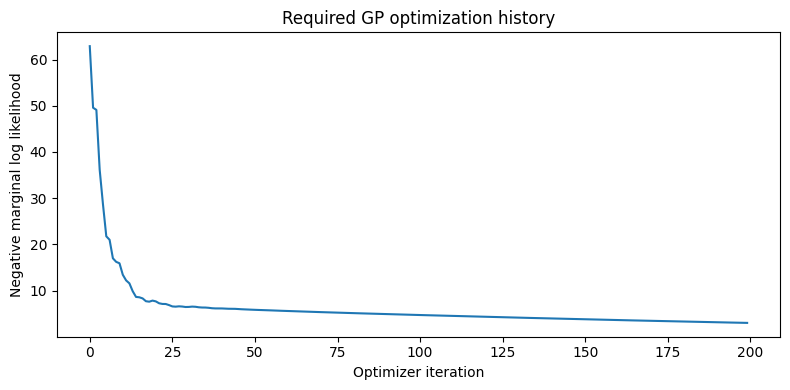

In [8]:
losses = np.asarray(fit_result["loss"], dtype=float)
assert losses.size >= MINITER
assert np.all(np.isfinite(losses))

with preserve_single_source_analysis_state(seed=SEED):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(losses)
    ax.set_xlabel("Optimizer iteration")
    ax.set_ylabel("Negative marginal log likelihood")
    ax.set_title("Required GP optimization history")
    fig.tight_layout()
    plt.show()


## 5. Predictions and maintained fitted-light-curve plots

Predictions are generated only after the fit has succeeded. The training-point
summary provides finite predictive means and variances and row-aligned residuals.
The maintained `Lightcurve.plot()` API is then called with provenance
annotations.


In [9]:
with preserve_single_source_analysis_state(
    seed=SEED,
    default_dtype=torch.float64,
):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=GPInputWarning)
        predictions = training_point_prediction_summary(lightcurve)

assert np.all(np.isfinite(predictions["predictive_mean"]))
assert np.all(np.isfinite(predictions["predictive_variance"]))
assert np.all(predictions["predictive_variance"] >= 0.0)
assert np.all(np.isfinite(predictions["residual"]))

stage_records.append(
    {
        "stage": "predictions",
        "status": "completed",
        "n_predictions": len(predictions["predictive_mean"]),
    }
)


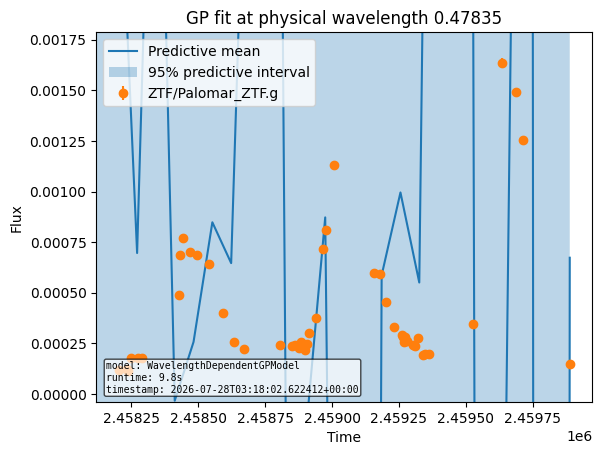

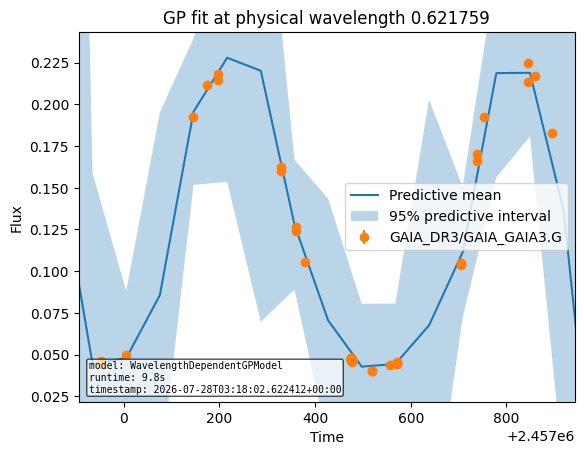

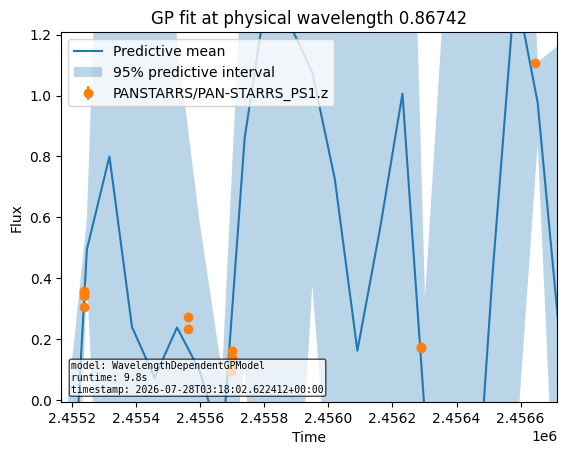

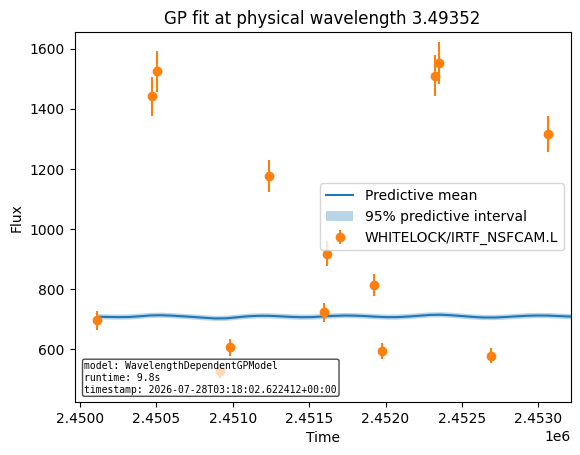

In [10]:
with preserve_single_source_analysis_state(seed=SEED):
    with warnings.catch_warnings(record=True) as plot_warning_records:
        warnings.simplefilter("always")
        fitted_lightcurve_figures = lightcurve.plot(
            show=False,
            save=False,
            n_pred=140,
            annotate_provenance=True,
        )

plot_warning_messages = [
    str(item.message) for item in plot_warning_records
]
assert len(fitted_lightcurve_figures) == 16
assert all(figure.axes for figure in fitted_lightcurve_figures)

selected_figure_indices = np.unique(
    np.rint(
        np.linspace(0, len(fitted_lightcurve_figures) - 1, 4)
    ).astype(int)
)
for figure_index, figure in enumerate(fitted_lightcurve_figures):
    if figure_index in selected_figure_indices:
        display(figure)
    plt.close(figure)

stage_records.append(
    {
        "stage": "plots",
        "status": "completed",
        "figure_count": len(fitted_lightcurve_figures),
        "warning_count": len(plot_warning_messages),
    }
)


## 6. Residual and phase diagnostics

Residuals are retained by observational channel rather than merged only by
physical wavelength. Phase folding uses the fitted consensus-period summary and
is diagnostic: it does not create a new period estimate or prove a wavelength
lag.


observational_channel,physical_wavelength,n_points,standardized_residual_rms,status
PANSTARRS/PAN-STARRS_PS1.i,0.753496,17,3.18242,severe
WHITELOCK/CTIO_OSIRIS.H,1.62539,14,2.14108,warning
WHITELOCK/CTIO_OSIRIS.K,2.1763,14,8.66388,severe
WHITELOCK/IRTF_NSFCAM.L,3.49352,14,7.84439,severe


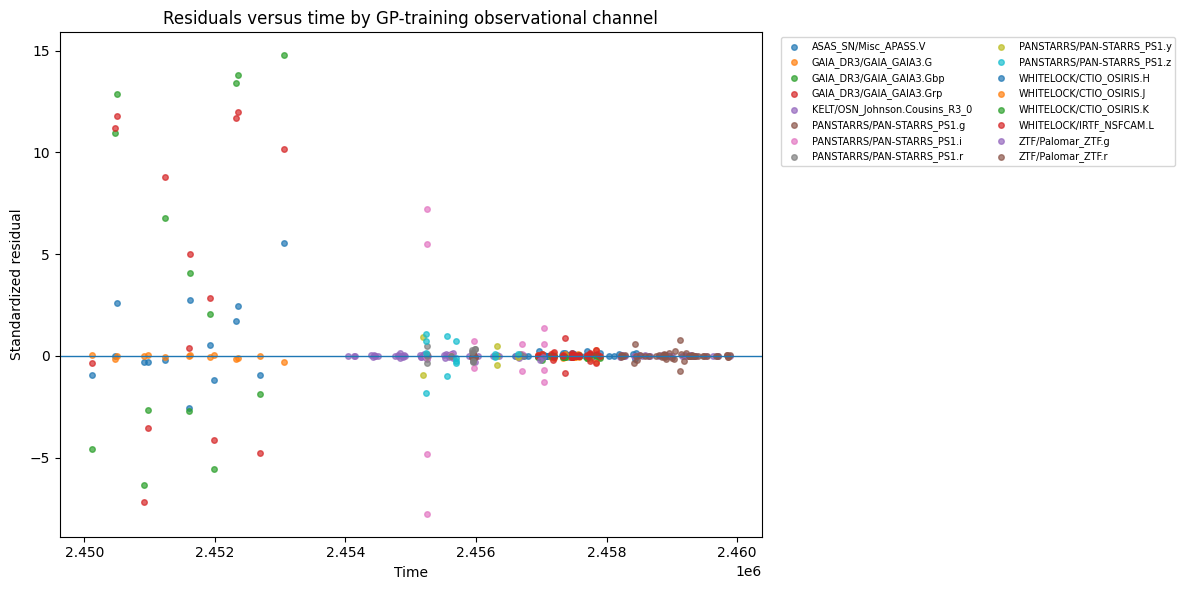

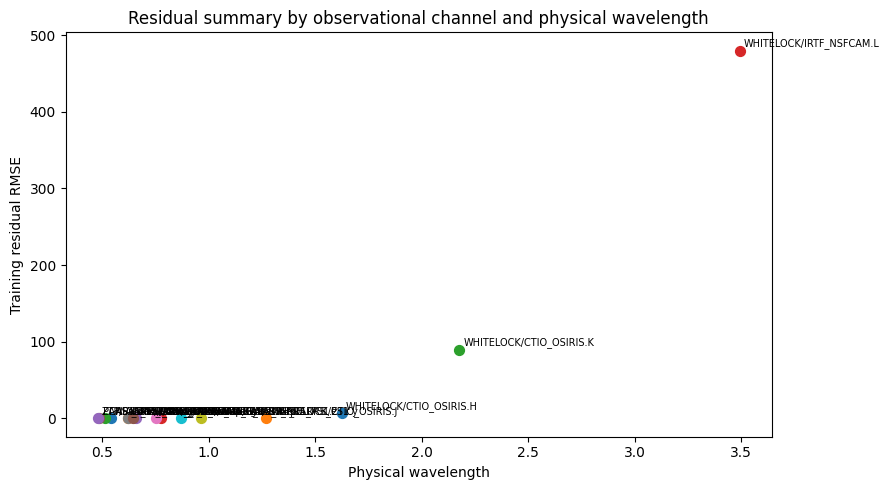

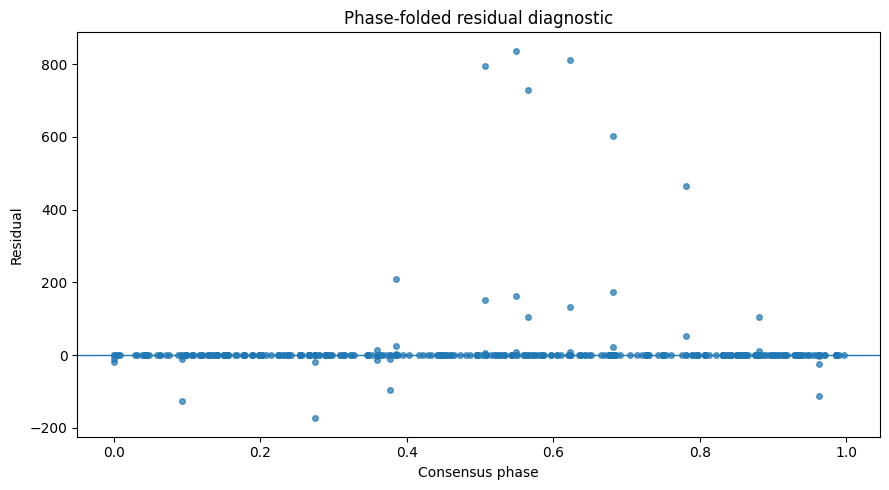

In [11]:
channel_residual_rows = summarize_observational_channel_residuals(
    predictions
)
phase_diagnostics = build_phase_folded_prediction_summary(
    predictions,
    period=consensus_period,
)

assert len(channel_residual_rows) == 16
assert len(phase_diagnostics["observational_channel_rows"]) == 16

fit_quality = summarize_single_source_fit_quality(
    channel_residual_rows,
    warning_threshold=2.0,
    severe_threshold=3.0,
)
fit_quality_warning_messages = fit_quality["warning_messages"]

display_records(
    fit_quality["channels_requiring_review"],
    columns=[
        "observational_channel",
        "physical_wavelength",
        "n_points",
        "standardized_residual_rms",
        "status",
    ],
    title="Observational channels requiring fit-quality review",
)

stage_records.append(
    {
        "stage": "residuals",
        "status": "completed",
        "n_observational_channels": len(channel_residual_rows),
        "fit_quality_status": fit_quality["status"],
        "n_channels_requiring_review": fit_quality[
            "n_channels_requiring_review"
        ],
    }
)

with preserve_single_source_analysis_state(seed=SEED):
    fig, ax = plt.subplots(figsize=(12, 6))
    prediction_channels = np.asarray(
        predictions["observational_channel"],
        dtype=str,
    )
    for observational_channel in dict.fromkeys(
        prediction_channels.tolist()
    ):
        channel_mask = prediction_channels == observational_channel
        ax.scatter(
            predictions["time"][channel_mask],
            predictions["standardized_residual"][channel_mask],
            s=16,
            alpha=0.7,
            label=observational_channel,
        )
    ax.axhline(0.0, linewidth=1)
    ax.set_xlabel("Time")
    ax.set_ylabel("Standardized residual")
    ax.set_title("Residuals versus time by GP-training observational channel")
    ax.legend(
        fontsize=7,
        ncol=2,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    fig.tight_layout()
    plt.show()

with preserve_single_source_analysis_state(seed=SEED):
    fig, ax = plt.subplots(figsize=(9, 5))
    for row in channel_residual_rows:
        ax.scatter(row["physical_wavelength"], row["rmse"], s=50)
        ax.annotate(
            row["observational_channel"],
            (row["physical_wavelength"], row["rmse"]),
            fontsize=7,
            xytext=(3, 3),
            textcoords="offset points",
        )
    ax.set_xlabel("Physical wavelength")
    ax.set_ylabel("Training residual RMSE")
    ax.set_title(
        "Residual summary by observational channel and physical wavelength"
    )
    fig.tight_layout()
    plt.show()

with preserve_single_source_analysis_state(seed=SEED):
    fig, ax = plt.subplots(figsize=(9, 5))
    phase_values = np.asarray(phase_diagnostics["phase"], dtype=float)
    residual_values = np.asarray(
        phase_diagnostics["residual"],
        dtype=float,
    )
    ax.scatter(phase_values, residual_values, s=16, alpha=0.7)
    ax.axhline(0.0, linewidth=1)
    ax.set_xlabel("Consensus phase")
    ax.set_ylabel("Residual")
    ax.set_title("Phase-folded residual diagnostic")
    fig.tight_layout()
    plt.show()


## 7. Structured fit, provenance, warning, and failure outputs

The compact report is JSON-safe and records every scientific stage, the
per-channel period evidence, consensus diagnostics, wavelength constraints,
fit history, predictions, residuals, phase diagnostics, channel-level
fit-quality screening, noise provenance, duplicate-wavelength resolution,
warnings, and runtime metadata. The fit-quality screen promotes standardized
residual RMS above 2 to review warnings and labels values above 3 severe; it is
not an automatic model-rejection rule. JSON export is available but disabled by
default so executing the public notebook does not write an untracked artifact
unexpectedly.


In [12]:
fit_summary = build_tutorial_fit_summary(
    model_name="2DWavelengthDependent",
    lightcurve=lightcurve,
    fit_result=fit_result,
    sampling_summary=sampling_summary,
    constraint_rows=constraint_rows,
    predictions=predictions,
    warning_messages=fit_warning_messages,
)

stage_records.append(
    {
        "stage": "structured_outputs",
        "status": "completed",
    }
)
validated_stage_records = validate_single_source_stage_records(stage_records)
assert [
    record["stage"] for record in validated_stage_records
] == list(SINGLE_SOURCE_ANALYSIS_STAGE_ORDER)

analysis_report = build_single_source_analysis_report(
    source_id="10131+3049",
    source_path="examples/data/10131+3049.csv",
    stage_records=validated_stage_records,
    input_summary={
        "sampling": sampling_summary,
        "observational_channels": input_summary,
    },
    period_evidence=period_evidence,
    consensus={
        "period_summary": single_source_json_safe(period_summary),
        "consensus_diagnostics": consensus_diagnostics,
    },
    wavelength_evidence={
        "parameter_workflow_report": parameter_workflow_report,
    },
    constraint_diagnostics={
        "constraint_rows": constraint_rows,
    },
    fit_diagnostics={
        "fit_summary": fit_summary,
        "fit_history": fit_history,
        "loss": losses,
    },
    prediction_diagnostics={
        "n_predictions": len(predictions["predictive_mean"]),
        "nonfinite_mean_count": int(
            np.count_nonzero(
                ~np.isfinite(predictions["predictive_mean"])
            )
        ),
        "nonfinite_variance_count": int(
            np.count_nonzero(
                ~np.isfinite(predictions["predictive_variance"])
            )
        ),
    },
    residual_diagnostics={
        "observational_channel_rows": channel_residual_rows,
        "overall_rmse": fit_summary["residual_rmse"],
        "fit_quality": fit_quality,
    },
    phase_diagnostics=phase_diagnostics,
    noise_provenance=noise_provenance,
    duplicate_wavelength_resolution=duplicate_wavelength_resolution,
    warnings=(
        fit_warning_messages
        + plot_warning_messages
        + fit_quality_warning_messages
    ),
    failures=[],
)

if WRITE_JSON_REPORT:
    written_report = write_single_source_analysis_report(
        REPORT_PATH,
        analysis_report,
    )
    print(f"Wrote {written_report}")

display_records(
    [
        {
            "schema": analysis_report["schema"],
            "source": analysis_report["source_id"],
            "completed stages": len(
                analysis_report["stage_records"]
            ),
            "consensus period": consensus_period,
            "fit iterations": fit_summary["n_iterations"],
            "GP training rows": fit_summary["gp_training_scope"][
                "n_observations"
            ],
            "consensus input rows": fit_summary["consensus_input_scope"][
                "n_observations"
            ],
            "objective improved": fit_summary["objective_improved"],
            "residual RMSE": fit_summary["residual_rmse"],
            "fit_quality_status": fit_quality["status"],
            "channels requiring review": fit_quality[
                "n_channels_requiring_review"
            ],
            "warning count": len(analysis_report["warnings"]),
            "failure count": len(analysis_report["failures"]),
        }
    ],
    title="Complete single-source analysis summary",
)


schema,source,completed stages,consensus period,fit iterations,GP training rows,consensus input rows,objective improved,residual RMSE,fit_quality_status,channels requiring review,warning count,failure count
pgmuvi.single_source_analysis,10131+3049,11,630.468,200,469,519,True,84.3398,requires_review,4,3,0


## Interpretation and limitations

This notebook demonstrates that the requested workflow can run on the one real
source distributed with PGMUVI. It does **not** establish a population-level
model preference, validate instrument-channel calibration, or prove that a
parameter near a constraint boundary is physically achromatic. The KELT
`R3_0`/`R3_1` selection applies only to exact-GP training; both KELT channels were
used independently for period evidence and were available to consensus.

For this source, the executed fit may complete while one or more observational
channels still require scientific review because their standardized residual RMS
is large. Completion is therefore not equivalent to fit adequacy. For a new
source, inspect rejected channels, harmonic or alias ambiguity, optimizer
history, live constraints, additional-noise magnitude, residual structure,
channel-level fit-quality warnings, and phase coverage before accepting the fit
scientifically.
